# Financial Market Data Analysis

This notebook performs a **time‑series analysis of selected financial instruments** using market data fetched from Yahoo Finance.

It is structured as a professional, end‑to‑end workflow:

- **Objective**: Analyse historical price behaviour of selected tickers and derive insights.
- **Data Source**: Yahoo Finance via the `yfinance` Python library.
- **Tools**: `pandas` for data wrangling, and any plotting/statistical libraries used later in the notebook.

> **Tip**: Run the notebook from top to bottom after configuring any parameters (tickers, date ranges, intervals) in the setup cells below.

## 1. Environment Setup & Data Download

In this section we:

- **Import core libraries** such as `yfinance`, `pandas`, and `datetime`.
- **Define helper functions** to download historical price data from Yahoo Finance in a modular way.
- **Configure key parameters** like the list of tickers, interval, and look‑back period.

Make sure you have installed the required Python packages before running these cells (see `README.md` for setup instructions).

In [ ]:
# %pip install yfinance 
# %pip install pandas 
# %pip install numpy 
# %pip install seaborn 
# %pip install matplotlib
# %pip install backtrader

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
from datetime import datetime

In [93]:
def fetch_stock_data(tickers, interval="1d", period=None, start=None, end=None):
    """
    Modular function to fetch historical data from Yahoo Finance.
    
    :param tickers: List of strings (e.g., ['AAPL', 'BTC-USD'])
    :param interval: Timeframe (1m, 2m, 5m, 15m, 30m, 60m, 90m, 1h, 1d, 5d, 1wk, 1mo, 3mo)
    :param period: Relative range (1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max)
    :param start: Start date string (YYYY-MM-DD)
    :param end: End date string (YYYY-MM-DD)
    """
    try:
        print(f"Fetching {interval} data for: {', '.join(tickers)}...")
        
        # yf.download handles multiple tickers and date logic automatically
        data = yf.download(
            tickers=tickers,
            interval=interval,
            period=period,
            start=start,
            end=end,
            group_by='ticker',  
            auto_adjust=True,    
            threads=True        
        )
        
        if data.empty:
            print("No data found for the given parameters.")
            return None
            
        return data

    except Exception as e:
        print(f"An error occurred: {e}")
        return None


In [94]:
def clean_df(df):
    df.drop_duplicates(subset=df.columns, keep='first', inplace=True)
    df.dropna(inplace=True)
    return df 

In [95]:
symbols = ["AAPL", "TSLA", "NVDA"]
timeframe = "1d"

data_period = "3y" 
try:
    # 1. Fetch data
    raw_data = yf.download(
        tickers=symbols,
        interval=timeframe,
        period=data_period,
        group_by='ticker',
        auto_adjust=True
    )
    # 2. Reshape from Wide (MultiIndex) to Long format
    # .stack(level=0) moves the Ticker names from the columns to the index
    long_format = raw_data.stack(level=0, future_stack=True)
    
    # 3. Clean up the index
    # This turns 'Date' and 'Ticker' from index levels into regular columns
    df_final = long_format.reset_index()
    
    # 4. Rename columns for clarity
    df_final = df_final.rename(columns={'level_1': 'Symbol'})
    
except Exception as e:
    print(f"Error: {e}")
df_final.set_index('Date', inplace=True)   
df_final.index = pd.to_datetime(df_final.index)
df_final = clean_df(df_final) 
df_final.to_csv("data_tickers.csv")


[*********************100%***********************]  3 of 3 completed


## 2. Data Processing & Feature Engineering
In this section, we calculate **various features** on our stock data.

In [96]:
grouped = df_final.groupby('Ticker', group_keys=False)
df_final['Close_-1'] = grouped['Close'].transform(lambda x: x.shift(1))
df_final['daily_returns'] = (df_final['Close'] - df_final['Close_-1']) / df_final['Close_-1']
df_final['log_returns'] = np.log(df_final['Close']) - np.log(df_final['Close_-1'])
df_final['volatility'] = grouped['daily_returns'].transform(lambda x: x.rolling(window=30).std())
df_final['mean_daily_returns'] = grouped['daily_returns'].transform(lambda x: x.expanding().mean())
df_final['ann_volatility'] = df_final['volatility'] * np.sqrt(252)

In [97]:
tickers = df_final['Ticker'].unique()
for ticker in tickers:
    df_ticker = df_final[df_final['Ticker'] == ticker]
    print(f'Ticker: {ticker} ')
    print(f'Mean Daily Return: {df_ticker['mean_daily_returns'].iloc[-1]}')
    print(f'Annualized Vol: {df_ticker['ann_volatility'].iloc[-1]}') 

Ticker: TSLA 
Mean Daily Return: 0.0016523971859654194
Annualized Vol: 0.36585035261844956
Ticker: AAPL 
Mean Daily Return: 0.0008609516789326834
Annualized Vol: 0.29092240366323574
Ticker: NVDA 
Mean Daily Return: 0.0032002640134305292
Annualized Vol: 0.4083822408428661


In [98]:
df = df_final.reset_index()

## 3. Data Visualization
In this section, we **visualize** various features.

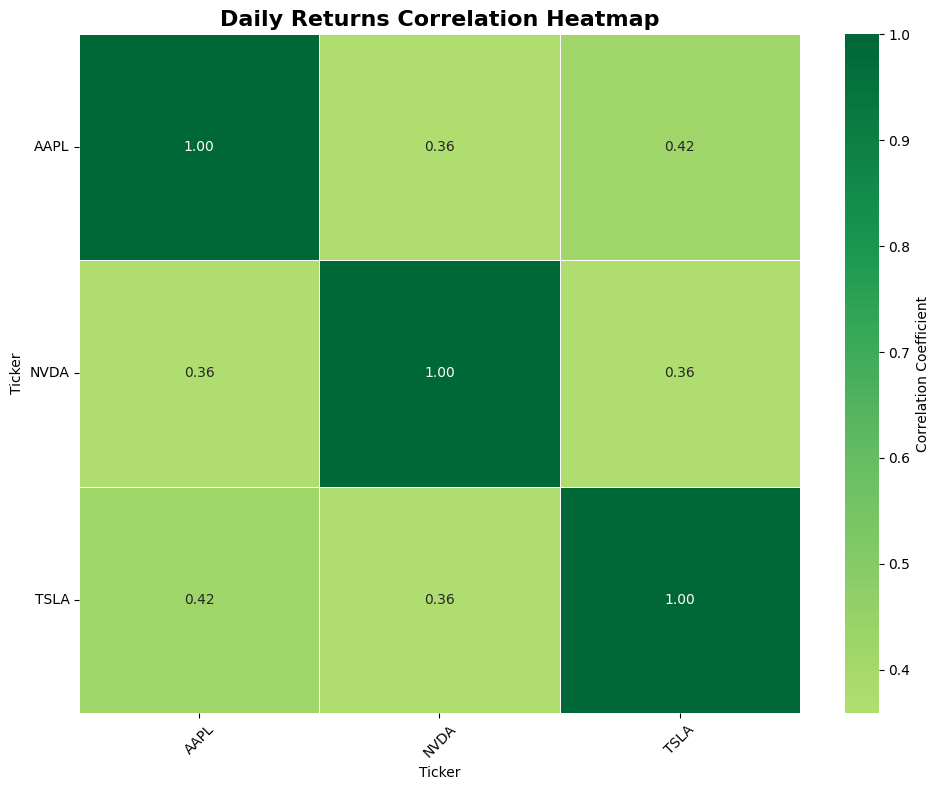

In [99]:
corr_df = df.pivot(index='Date', columns='Ticker', values='daily_returns')

correlation_matrix = corr_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Show the numbers in the boxes
    fmt=".2f",           # Format to 2 decimal places
    cmap='RdYlGn',       # Red (negative), Yellow (neutral), Green (positive)
    center=0,            # Ensure 0 is the neutral color
    linewidths=0.5,      # Add small gaps between boxes
    cbar_kws={"label": "Correlation Coefficient"}
)

plt.title('Daily Returns Correlation Heatmap', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()


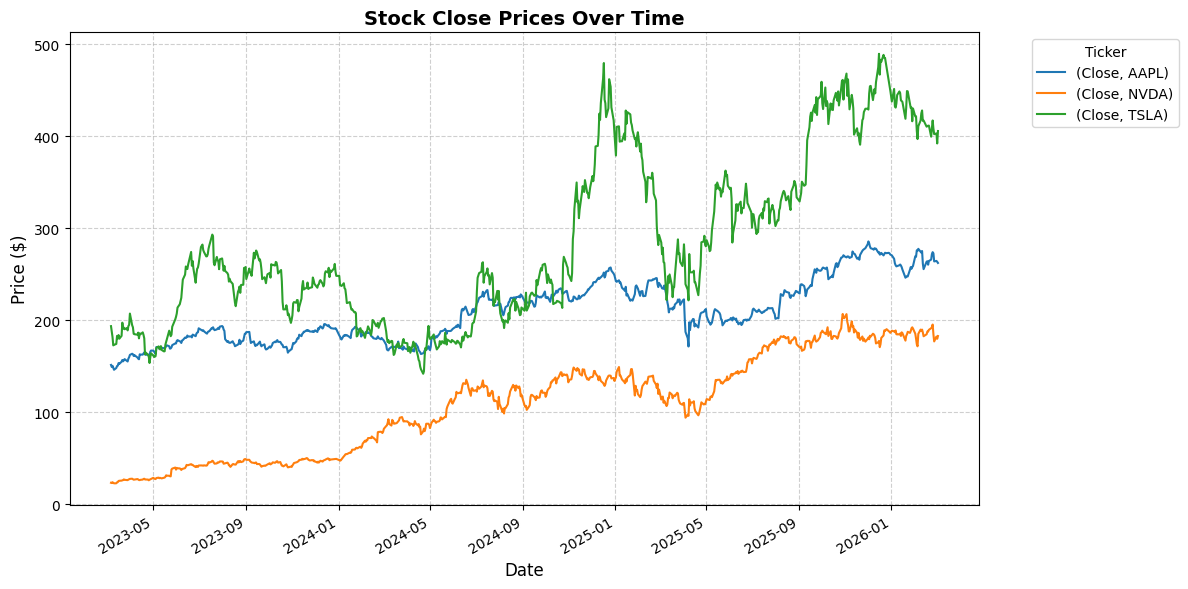

In [100]:
price_pivot = df.pivot(index='Date', columns='Ticker', values=['Close'])
price_pivot.plot(figsize=(12, 6), linewidth=1.5)
plt.title('Stock Close Prices Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend(title='Ticker', bbox_to_anchor=(1.05, 1), loc='upper left') # Legend outside to avoid overlap
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout() # Ensures labels aren't truncated


## 4. Backtesting
In this section, we **backtest** various strategies.
1) **SMA Crossover STRATEGY**
2) **BUY AND HOLD STRATEGY** 

In [101]:
import backtrader as bt 
def create_pandasdata_class(custom_columns):
    """
    Dynamically create a custom PandasData subclass
    with user-defined extra lines and params.
    """
    base_params = [
        ('datetime', None),
        ('open', 'Open'),
        ('high', 'High'),
        ('low', 'Low'),
        ('close', 'Close'),
        ('volume', 'Volume'),
    ]

    # Add your custom columns
    for col in custom_columns:
        base_params.append((col, col))

    # Create and return a new subclass dynamically
    return type(
        'DynamicPandasData',             # name of new class
        (bt.feeds.PandasData,),          # parent class
        {
            'lines': tuple(custom_columns),
            'params': tuple(base_params),
        }
    )
def backtest_single_asset(df, strategy_cls, initial_cash, custom_cols, commission=0.04, slippage=0.1):
    cerebro = bt.Cerebro()
    cerebro.broker.set_slippage_perc(slippage)  # 0.1% slippage
    cerebro.broker.set_coc(True)  # Market orders execute on current bar close

    # cerebro.addstrategy(strategy_cls, adx_mean=df['ADX_14'].mean(), adx_std=df['ADX_14'].std(), diff_mean=(df['DMN_14'] - df['DMP_14']).mean(), diff_std=(df['DMN_14'] - df['DMP_14']).std() )
    # cerebro.addstrategy(strategy_cls, vwap_mean=df_filtered['vwap'].mean(), vwap_std=df_filtered['vwap'].std())
    cerebro.addstrategy(strategy_cls)
    # Load data
    DynamicDataClass = create_pandasdata_class(custom_cols)

# Now you can use it like a normal Backtrader data feed
    data = DynamicDataClass(dataname=df)
    cerebro.adddata(data)

    # Broker
    cerebro.broker.setcash(initial_cash)
    cerebro.broker.setcommission(commission=commission)
    cerebro.broker.set_shortcash(True)  # allow shorts

    # Analyzers
    cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='trades')
    cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe')
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')
    cerebro.addanalyzer(bt.analyzers.Returns, _name='returns')

    results = cerebro.run()
    strat = results[0]
    return strat


In [102]:
import talib
def calculate_sma(df, period=14, source_col="c"): 
    df[f'SMA_{period}'] = talib.SMA(
        real=df[source_col],
        timeperiod=period
    )
    return df

In [103]:
import backtrader as bt
import pandas as pd

class SMACrossoverStrategy(bt.Strategy):
    def __init__(self):
        # Keeping your variable names exactly the same
        self.sma_fast = self.data.SMA_50
        self.sma_slow = self.data.SMA_20
        self.crossover = self.data.crossover
        self.order = None
        
        # New dictionary to "hold" the data between entry and exit
        self.active_trades = {} 
        self.trade_log = []
        self.portfolio_values = []

    def notify_trade(self, trade):
        # 1. Capture data when trade opens (while size still exists)
        if trade.justopened:
            self.active_trades[trade.ref] = {
                'Entry_Price': trade.price,
                'Quantity': abs(trade.size)
            }

        # 2. When trade closes, use the stored data to fill your trade_log
        elif trade.isclosed:
            if trade.ref in self.active_trades:
                # Get the stored data and remove it from active list
                stored = self.active_trades.pop(trade.ref)
                
                # Keep your exact keys and logic
                self.trade_log.append({
                    'Entry_Time': bt.num2date(trade.dtopen),
                    'Exit_Time': bt.num2date(trade.dtclose),
                    'Entry_Price': stored['Entry_Price'],
                    'Exit_Price': self.data.close[0], # Keeping your exit price logic
                    'Quantity': stored['Quantity'],   # Now this won't be 0.0
                    'Position_Status': 1.0,           # Static since you only do Long
                    'PnL': trade.pnlcomm, 
                    'PnL_Net_%': (trade.pnlcomm / (stored['Entry_Price'] * stored['Quantity'])) * 100 if stored['Entry_Price'] else 0
                })
                
                self.log(f'TRADE CLOSED: PnL {trade.pnlcomm:.2f}')

    def notify_order(self, order):
        if order.status in [order.Completed]:
            price = order.executed.price
            if order.isbuy():
                self.log(f'BUY EXECUTED at {price}')
            elif order.issell():
                self.log(f'SELL EXECUTED at {price}')
        elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            self.log('Order Canceled/Margin/Rejected')
        self.order = None

    def next(self):
        # Tracking portfolio value
        self.portfolio_values.append({
            'datetime': self.datas[0].datetime.datetime(0),
            'value': self.broker.get_value()
        })

        if not self.position:
            if self.crossover[0] > 0:
                size = (self.broker.get_cash() * 0.9) // self.data.close[0]
                if size > 0:
                    self.log(f'BUY CREATE {int(size)} shares at {self.data.close[0]:.2f}')
                    self.buy(size=size)
        else:
            if self.crossover[0] < 0:
                self.log(f'SELL CREATE at {self.data.close[0]:.2f}')
                self.close()

    def log(self, txt, dt=None):
        dt = dt or self.datas[0].datetime.datetime(0)
        print(f'{dt.isoformat()}, {txt}')

In [104]:
nvda_df = df_final[df_final['Ticker'] == 'NVDA']
nvda_df = calculate_sma(nvda_df, period=20, source_col="Close")
nvda_df = calculate_sma(nvda_df, period=50, source_col="Close")

import numpy as np 
nvda_df['crossover'] = np.where(nvda_df['SMA_20'] > nvda_df['SMA_50'], 1, -1)
# nvda_df = clean_df(nvda_df)

C:\Users\aryan\AppData\Local\Temp\ipykernel_22152\3806427404.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'SMA_{period}'] = talib.SMA(
C:\Users\aryan\AppData\Local\Temp\ipykernel_22152\3806427404.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'SMA_{period}'] = talib.SMA(
C:\Users\aryan\AppData\Local\Temp\ipykernel_22152\1259239143.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

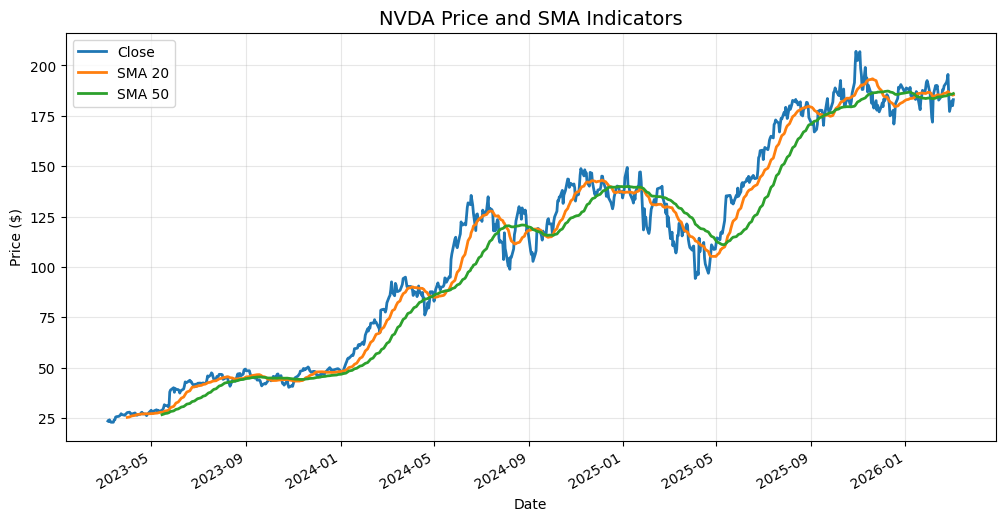

In [105]:
import matplotlib.pyplot as plt
target_ticker = 'NVDA'
features = ['Close', 'SMA_20', 'SMA_50']
pivot_features = nvda_df.reset_index().pivot(index='Date', columns='Ticker', values=features)
pivot_features.plot(figsize=(12, 6), linewidth=2)
plt.title(f'{target_ticker} Price and SMA Indicators', fontsize=14)
plt.ylabel('Price ($)')
plt.legend(['Close', 'SMA 20', 'SMA 50']) 
plt.grid(True, alpha=0.3)
plt.show()

In [106]:

def safe_get(d, *keys, default=0):
    """Safely get nested keys from AutoOrderedDict"""
    for key in keys:
        if key in d:
            d = d[key]
        else:
            return default
    return d
def get_detailed_metrics(strat):
    trades = strat.analyzers.trades.get_analysis()
    sharpe = strat.analyzers.sharpe.get_analysis()
    drawdown = strat.analyzers.drawdown.get_analysis()
    returns = strat.analyzers.returns.get_analysis()

    total_trades = safe_get(trades, 'total', 'closed')
    won_trades = safe_get(trades, 'won', 'total')
    lost_trades = safe_get(trades, 'lost', 'total')

    win_rate = (won_trades / total_trades * 100) if total_trades else 0
    loss_rate = (lost_trades / total_trades * 100) if total_trades else 0

    avg_win = safe_get(trades, 'won', 'pnl', 'average')
    avg_loss = safe_get(trades, 'lost', 'pnl', 'average')
    max_win = safe_get(trades, 'won', 'pnl', 'max')
    max_loss = safe_get(trades, 'lost', 'pnl', 'max')
    metrics = {
        'total_trades': total_trades,
        'winning_trades': won_trades,
        'losing_trades': lost_trades,
        'win_rate_%': win_rate,
        'loss_rate_%': loss_rate,
        'avg_win': avg_win,
        'avg_loss': avg_loss,
        'max_win': max_win,
        'max_loss': max_loss,
        # 'pnl': total_pnl,
        'sharpe_ratio': sharpe.get('sharperatio', 0),
        'max_drawdown_%': safe_get(drawdown, 'max', 'drawdown'),
        'max_drawdown_duration_bars': safe_get(drawdown, 'max', 'len'),
        'cumulative_return_%': returns.get('rtot', 0) * 100,
        'average_return_%': returns.get('ravg', 0) * 100,
        'volatility_%': returns.get('rstd', 0) * 100,
        'calmar_ratio': (returns.get('ravg',0)*100 / safe_get(drawdown,'max','drawdown')) if safe_get(drawdown,'max','drawdown') else 0,
        'profit_factor': (avg_win * won_trades) / abs(avg_loss * lost_trades) if lost_trades > 0 else float('inf'),
        'expectancy_per_trade': (win_rate/100)*avg_win - (loss_rate/100)*abs(avg_loss)
    }

    df_portfolio = pd.DataFrame(strat.portfolio_values)
    df_tradelog  = pd.DataFrame(strat.trade_log)
    return metrics, df_portfolio, df_tradelog


In [107]:
custom_cols = ['SMA_20', 'SMA_50', 'crossover']
nvda_df.columns

Index(['Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'Close_-1',
       'daily_returns', 'log_returns', 'volatility', 'mean_daily_returns',
       'ann_volatility', 'SMA_20', 'SMA_50', 'crossover'],
      dtype='object', name='Price')

In [108]:
sma_strat = backtest_single_asset(nvda_df, strategy_cls=SMACrossoverStrategy, initial_cash=100000, custom_cols=custom_cols)
sma_metrics, portfolio_df, trade_log_df = get_detailed_metrics(strat=sma_strat)

2023-05-15T00:00:00, BUY CREATE 3111 shares at 28.93
2023-05-16T00:00:00, BUY EXECUTED at 29.845197623603145
2023-09-27T00:00:00, SELL CREATE at 42.44
2023-09-28T00:00:00, SELL EXECUTED at 42.08785097086144
2023-09-28T00:00:00, TRADE CLOSED: PnL 29135.55
2023-11-15T00:00:00, BUY CREATE 2378 shares at 48.86
2023-11-16T00:00:00, BUY EXECUTED at 49.49307401570829
2024-04-30T00:00:00, SELL CREATE at 86.36
2024-05-01T00:00:00, SELL EXECUTED at 81.21354987762143
2024-05-01T00:00:00, TRADE CLOSED: PnL 62998.48
2024-05-20T00:00:00, BUY CREATE 1825 shares at 94.73
2024-05-21T00:00:00, BUY EXECUTED at 95.35135699716332
2024-08-02T00:00:00, SELL CREATE at 107.22
2024-08-05T00:00:00, SELL EXECUTED at 96.50168838500977
2024-08-05T00:00:00, TRADE CLOSED: PnL -11905.92
2024-09-06T00:00:00, BUY CREATE 1578 shares at 102.79
2024-09-09T00:00:00, BUY EXECUTED at 106.50442134190934
2024-09-19T00:00:00, SELL CREATE at 117.83
2024-09-20T00:00:00, SELL EXECUTED at 115.35050480567513
2024-09-20T00:00:00, TRAD

In [109]:
metrics_df = pd.DataFrame({'metric': sma_metrics.keys(), 'sma_strat': sma_metrics.values()})
metrics_df.set_index('metric', inplace=True)


In [110]:
trade_log_df


,Entry_Time,Exit_Time,Entry_Price,Exit_Price,Quantity,Position_Status,PnL,PnL_Net_%
0,2023-05-16,2023-09-28,29.8452,43.0612,3111.0000,1.0000,29135.5460,31.3797
1,2023-11-16,2024-05-01,49.4931,82.9986,2378.0000,1.0000,62998.4775,53.5271
2,2024-05-21,2024-08-05,95.3514,100.4070,1825.0000,1.0000,-11905.9175,-6.8418
3,2024-09-09,2024-09-20,106.5044,115.9603,1578.0000,1.0000,-44.3632,-0.0264
4,2024-10-03,2024-12-18,124.3174,128.8748,1364.0000,1.0000,-8422.7019,-4.9671
5,2025-05-15,2025-09-18,136.2753,176.2302,1142.0000,1.0000,27757.5562,17.8360
6,2025-10-06,2025-12-03,187.2196,179.5800,957.0000,1.0000,-21793.1129,-12.1634
7,2026-01-16,2026-03-03,190.4400,180.0500,855.0000,1.0000,-24123.3157,-14.8154


In [111]:
import backtrader as bt
import pandas as pd

class BuyAndHoldStrategy(bt.Strategy):
    params = (
        ('hold_bars', 749), # Example: Exit after 50 bars
    )

    def __init__(self):
        self.sma_fast = self.data.SMA_50
        self.sma_slow = self.data.SMA_20
        self.crossover = self.data.crossover
        self.order = None
        
        self.active_trades = {} 
        self.trade_log = []
        self.portfolio_values = []
        
        # Track the bar index where we entered
        self.entry_bar = None

    def notify_trade(self, trade):
        if trade.justopened:
            self.active_trades[trade.ref] = {
                'Entry_Price': trade.price,
                'Quantity': abs(trade.size)
            }

        elif trade.isclosed:
            if trade.ref in self.active_trades:
                stored = self.active_trades.pop(trade.ref)
                
                self.trade_log.append({
                    'Entry_Time': bt.num2date(trade.dtopen),
                    'Exit_Time': bt.num2date(trade.dtclose),
                    'Entry_Price': stored['Entry_Price'],
                    'Exit_Price': self.data.close[0],
                    'Quantity': stored['Quantity'],
                    'Position_Status': 1.0,
                    'PnL': trade.pnlcomm, 
                    'PnL_Net_%': (trade.pnlcomm / (stored['Entry_Price'] * stored['Quantity'])) * 100 if stored['Entry_Price'] else 0
                })
                self.log(f'TRADE CLOSED: PnL {trade.pnlcomm:.2f}')

    def notify_order(self, order):
        if order.status in [order.Completed]:
            if order.isbuy():
                # Record the current length of the strategy as the entry bar
                self.entry_bar = len(self)
                self.log(f'BUY EXECUTED at {order.executed.price}')
            elif order.issell():
                self.log(f'SELL EXECUTED at {order.executed.price}')
        
        elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            self.log('Order Canceled/Margin/Rejected')
        self.order = None

    def next(self):
        self.portfolio_values.append({
            'datetime': self.datas[0].datetime.datetime(0),
            'value': self.broker.get_value()
        })

        # 1. ENTRY: Buy if we have no position and no pending order
        if not self.position and not self.order:
            size = (self.broker.get_cash() * 0.9) // self.data.close[0]
            if size > 0:
                self.log(f'ENTRY CREATE {int(size)} shares')
                self.order = self.buy(size=size)

        # 2. EXIT: Check if we have held for the required number of bars
        else:
            if self.entry_bar is not None:
                # Calculate how many bars have passed since entry
                bars_held = len(self) - self.entry_bar
                
                if bars_held >= self.params.hold_bars:
                    self.log(f'EXIT TRIGGERED: Held for {bars_held} bars.')
                    self.close()
                    self.entry_bar = None # Reset for next potential trade

    def log(self, txt, dt=None):
        dt = dt or self.datas[0].datetime.datetime(0)
        print(f'{dt.isoformat()}, {txt}')

In [112]:
buy_and_hold_strat = backtest_single_asset(nvda_df, strategy_cls=BuyAndHoldStrategy, initial_cash=100000, custom_cols=custom_cols)
buy_and_hold_metrics, portfolio_df, trade_log_df = get_detailed_metrics(strat=buy_and_hold_strat)

2023-03-06T00:00:00, ENTRY CREATE 3824 shares
2023-03-07T00:00:00, BUY EXECUTED at 24.104968314326598
2026-03-03T00:00:00, EXIT TRIGGERED: Held for 749 bars.
2026-03-04T00:00:00, SELL EXECUTED at 180.05999755859375
2026-03-04T00:00:00, TRADE CLOSED: PnL 565142.96
2026-03-04T00:00:00, ENTRY CREATE 3270 shares


In [113]:
metrics_df_2 = pd.DataFrame({'metric': buy_and_hold_metrics.keys(), 'buy_and_hold_strat': buy_and_hold_metrics.values()})
metrics_df_2.set_index('metric', inplace=True)
pd.options.display.float_format = '{:.4f}'.format
final_metrics_df = pd.concat([metrics_df,  metrics_df_2], axis=1)
final_metrics_df

,sma_strat,buy_and_hold_strat
metric,,
total_trades,8.0000,1.0000
winning_trades,3.0000,1.0000
losing_trades,5.0000,0.0000
win_rate_%,37.5000,100.0000
loss_rate_%,62.5000,0.0000
avg_win,39963.8599,565142.9587
avg_loss,-13257.8823,0.0000
max_win,62998.4775,565142.9587
max_loss,-24123.3157,0.0000
